# N1 · 学一个世界模型 + 脑内想象 rollout

> 配套 13.5-L1 · 玩具环境: 2D 智能体在方盒里, 动作=上下左右各推一步。
> 训一个世界模型学 (状态,动作)→Δ状态, 然后给它一串动作让它**想象**整条轨迹, 和真环境对照。
> 亲眼看「模型学会了世界怎么动」。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import world_model as wm
print('world_model 就绪, 动作数', wm.N_ACTIONS)

world_model 就绪, 动作数 4


## 1. 采转移样本 (state, action → Δstate) 训世界模型

In [2]:
torch.manual_seed(0)
data = wm.make_transitions(n=4000, seed=0)
print('转移样本:', data[0].shape, '个 (状态, 动作, Δ状态)')
model = wm.build_world_model()
losses = wm.train_world_model(model, data, epochs=400)
print(f'世界模型训练: loss {losses[0]:.4f} → {losses[-1]:.4f}')

转移样本: (4000, 2) 个 (状态, 动作, Δ状态)


世界模型训练: loss 0.0119 → 0.0003


## 2. 脑内想象 vs 真环境: 同一串动作, 看想象轨迹贴不贴真实

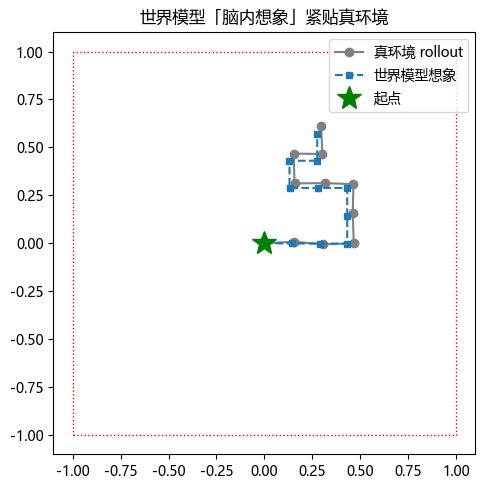

想象终点 [0.275 0.57 ]  真实终点 [0.295 0.613]  末端差 0.047
→ 世界模型学会了环境动态: 给动作就能想象未来, 不需要碰真环境 (model-based 规划的地基)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
start = np.array([0.0, 0.0], np.float32)
acts = [3,3,3,0,0,2,2,0,3,0]      # 一串动作 (右右右上上左左上右上)
img = wm.imagine(model, start, acts)        # 脑内想象 (不碰真环境)
tru = wm.true_rollout(start, acts, seed=1)  # 真环境
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(tru[:,0], tru[:,1], '-o', label='真环境 rollout', color='gray', ms=6)
ax.plot(img[:,0], img[:,1], '--s', label='世界模型想象', color='C0', ms=5)
ax.plot(*start, 'g*', ms=18, label='起点')
ax.add_patch(plt.Rectangle((-1,-1),2,2,fill=False,ls=':',ec='r'))
ax.legend(); ax.set_title('世界模型「脑内想象」紧贴真环境'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
print(f'想象终点 {img[-1].round(3)}  真实终点 {tru[-1].round(3)}  末端差 {np.linalg.norm(img[-1]-tru[-1]):.3f}')
print('→ 世界模型学会了环境动态: 给动作就能想象未来, 不需要碰真环境 (model-based 规划的地基)。')

## 3. 反思
你训了一个世界模型并用它**想象**了未来。带走:
- 世界模型 = 学转移 (状态,动作)→下一状态; 学会后能脑内 rollout, 不碰真环境。
- 实现智慧: 预测 **Δ状态 (变化量)** 比预测绝对状态更稳 (同扩散学噪声/ResNet 残差)。
- 用途: model-based 规划 (在想象里试动作)、省真实交互、机器人预演 (接 M11)。
下一步 N2: 想象越长越不准吗? 量化**多步误差累积** (世界模型核心难题)。